## 1️⃣ Linear Regression — Uber Ride Price Prediction (Big Dataset)
**Problem Statement:**

Uber wants to improve the accuracy of its fare estimation engine.
They need a model that predicts the ride price before the user books a trip.

Pricing depends on multiple factors such as:

Trip distance in kilometers

Expected travel time

Whether the trip occurs during peak hours

Your task is to analyze the dataset and build a Linear Regression model that predicts the final ride price.


**Goals:**

Perform full EDA

Identify the influence of each feature on price

Train Linear Regression with cross-validation

Evaluate using MAE, RMSE, and R²

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

## **EDA**

In [ ]:
df=pd.read_csv("/content/uber_missing.csv")

In [ ]:
df.head()

,distance_km,time_min,peak_hours,price
0,27.611723,91.178773,0.0,NaN
1,3.099020,10.898291,0.0,47.727413
2,9.594035,36.069314,NaN,188.815738
3,8.190501,23.800240,0.0,116.111687
4,7.860330,27.583466,1.0,196.818750


In [ ]:
df.tail()

,distance_km,time_min,peak_hours,price
895,2.000447,5.143265,0.0,59.721547
896,38.685532,159.839954,1.0,759.915722
897,14.777696,62.205608,1.0,NaN
898,22.816091,90.571115,NaN,421.985397
899,19.833842,NaN,1.0,NaN


In [ ]:
df.isnull()
df.isnull().sum()

,0
distance_km,100
time_min,123
peak_hours,123
price,105


In [ ]:
df["distance_km"]=df["distance_km"].fillna(df["distance_km"].mean())
df["time_min"]=df["time_min"].fillna(df["time_min"].mean())
df["peak_hours"]=df["peak_hours"].fillna(df["peak_hours"].mean())
df["price"]=df["price"].fillna(df["price"].mean())
df.sort_values(by="distance_km", ascending=True)

,distance_km,time_min,peak_hours,price
52,1.124063,8.160539,0.00000,36.950648
783,1.137215,4.404554,0.00000,94.490181
80,1.229711,7.844510,0.00000,78.264406
612,1.242197,3.697542,0.00000,353.775174
377,1.250730,64.783592,0.00000,57.156691
...,...,...,...,...
718,39.549357,128.876078,1.00000,683.329607
706,39.632258,125.684769,0.47619,645.731565
622,39.716361,161.010213,0.00000,687.481145
208,39.768819,108.441221,1.00000,604.205510


In [ ]:
df.groupby("peak_hours")["price"].mean()

,price
peak_hours,
0.00000,339.163960
0.47619,363.645208
1.00000,366.566389


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   distance_km  900 non-null    float64
 1   time_min     900 non-null    float64
 2   peak_hours   900 non-null    float64
 3   price        900 non-null    float64
dtypes: float64(4)
memory usage: 28.3 KB


In [ ]:
df.describe()

,distance_km,time_min,peak_hours,price
count,900.000000,900.000000,900.00000,900.000000
mean,20.404784,64.783592,0.47619,353.775174
std,10.454888,34.388505,0.46431,163.432651
min,1.124063,-1.095269,0.00000,17.601259
25%,11.926745,39.344833,0.00000,220.091172
50%,20.404784,64.783592,0.47619,353.775174
75%,28.710332,87.462548,1.00000,478.880818
max,39.900000,162.111538,1.00000,759.915722


In [ ]:
df.dtypes

,0
distance_km,float64
time_min,float64
peak_hours,float64
price,float64


In [ ]:
df.shape

(900, 4)

In [ ]:
df.index

RangeIndex(start=0, stop=900, step=1)

In [ ]:
df.size

3600

In [ ]:
df.ndim

2

In [ ]:
df.empty

False

In [ ]:
print(df)

     distance_km    time_min  peak_hours       price
0      27.611723   91.178773     0.00000  353.775174
1       3.099020   10.898291     0.00000   47.727413
2       9.594035   36.069314     0.47619  188.815738
3       8.190501   23.800240     0.00000  116.111687
4       7.860330   27.583466     1.00000  196.818750
..           ...         ...         ...         ...
895     2.000447    5.143265     0.00000   59.721547
896    38.685532  159.839954     1.00000  759.915722
897    14.777696   62.205608     1.00000  353.775174
898    22.816091   90.571115     0.47619  421.985397
899    19.833842   64.783592     1.00000  353.775174

[900 rows x 4 columns]


In [ ]:
df.isnull().sum()

,0
distance_km,0
time_min,0
peak_hours,0
price,0


## **ML**

1) load data
2) choose model
3) split
4) standardize
5) cv (train + predict train (70%) data for confirmation)
6) train again entire (70%)
7) predict test
8) predict random value
9) evaluate
10) plot graph

In [ ]:
#LOAD DATA
x=df[["distance_km","time_min","peak_hours"]]
y=df["price"]

In [ ]:
#CHOOSE MODEL
model=LinearRegression()

In [ ]:
#SPLIT
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.30)

In [ ]:
#STANDARDIZE
std=StandardScaler()
x_train_std=std.fit_transform(x_train)
x_test_std=std.transform(x_test)

In [ ]:
#CV
kf=KFold(n_splits=5)

In [ ]:
#PREDICTION OF TRAIN DATA
y_train_predict=cross_val_predict(model,x_train_std,y_train,cv=kf)

In [ ]:
#TRAIN
model.fit(x_train_std,y_train)

LinearRegression()

In [ ]:
#EVALUATION OF TRAIN DATA
msey=mean_squared_error(y_train, y_train_predict)
maet=mean_absolute_error(y_train, y_train_predict)
print(msey)
print(maet)

5143.188631623215
47.238490491763436


In [ ]:
#PREDICTION OF TEST DATA
y_test_predict=model.predict(x_test_std)

In [ ]:
#EVALUATION OF TEST DATA
msey=mean_squared_error(y_test,y_test_predict)
maey=mean_absolute_error(y_test,y_test_predict)

print(msey)
print(maey)

5057.277831397474
45.17427082790872


In [ ]:
new_val = model.predict(std.transform([[10,30,0.2]]))
print(new_val)

[198.12681857]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


<Axes: >

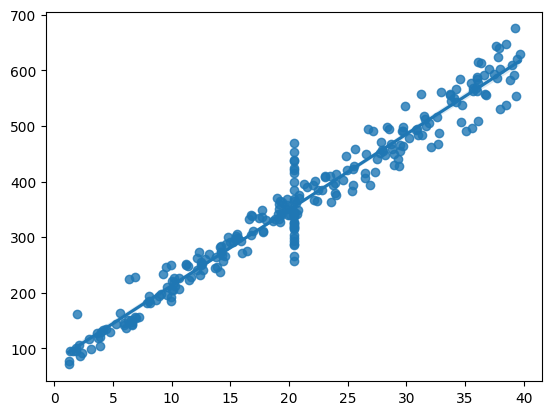

In [ ]:
xnew=x_test["distance_km"].to_numpy()

argid=np.argsort(xnew)
x_sort=xnew[argid]
y_sort=y_test_predict[argid]

sns.regplot(x=x_sort,y=y_sort)